In [26]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import kagglehub
import os
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics  import classification_report , confusion_matrix , accuracy_score

## **Load Dataset**

In [27]:
path = kagglehub.dataset_download("fahimabrarsami/brain-tumor")
print(path)

C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1


In [ ]:
print(os.listdir(path))

['Testing', 'Training']


['Testing', 'Training']


In [ ]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

print(train_path)
print(test_path)

C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1\Training
C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1\Testing


In [ ]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

print("Training:")
print(os.listdir(train_path))

print("\nTesting:")
print(os.listdir(test_path))

Training:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
for cls in os.listdir(train_path):
    train_count = len(os.listdir(os.path.join(train_path, cls)))
    test_count = len(os.listdir(os.path.join(test_path, cls)))

    print(f"{cls}:")
    print(f"  Training: {train_count}")
    print(f"  Testing : {test_count}")
    print()

glioma:
  Training: 1400
  Testing : 400

meningioma:
  Training: 1400
  Testing : 400

notumor:
  Training: 1400
  Testing : 400

pituitary:
  Training: 1400
  Testing : 400



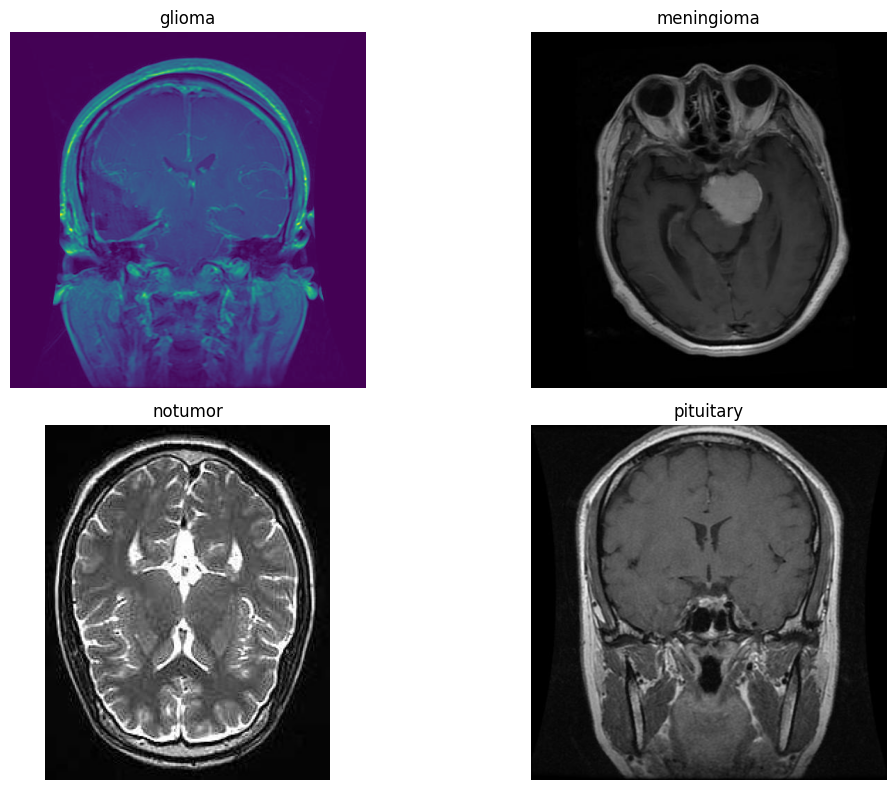

In [ ]:
classes = os.listdir(train_path)

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    
    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for cls in classes:
    folder = os.path.join(train_path, cls)
    
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    
    image = Image.open(image_path)
    
    print(f"{cls}: {image.size}")

glioma: (512, 512)
meningioma: (512, 512)
notumor: (201, 251)
pituitary: (512, 512)


In [ ]:
image_name = os.listdir(os.path.join(train_path, classes[0]))[0]
image_path = os.path.join(train_path, classes[0], image_name)

# Image load
image = Image.open(image_path).convert("RGB")

print("Original size:", image.size)

# Resize
image = image.resize((224, 224))

# Convert to NumPy array
image_array = np.array(image)

# Normalize
image_array = image_array / 255.0

print("After resize:", image_array.shape)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Original size: (512, 512)
After resize: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 0.9529411764705882


In [ ]:


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_dataset.class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Normalization + Augmentation

In [ ]:
# Normalize pixel values: 0-255 → 0-1
normalization_layer = layers.Rescaling(1./255)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

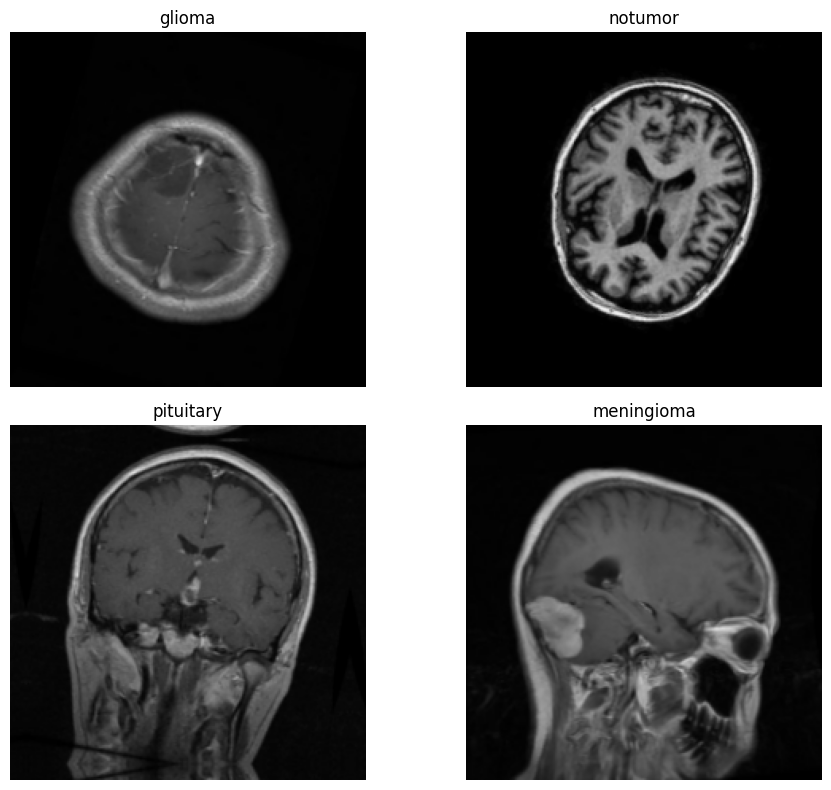

In [ ]:
# Training dataset batch 1
images, labels = next(iter(train_dataset))

# first 4 images
plt.figure(figsize=(10, 8))

for i in range(4):
    augmented_image = data_augmentation(images[i])

    plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_image.numpy().astype("uint8"))
    plt.title(train_dataset.class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()

plt.show()

Final Data Pipeline

In [ ]:
# Image size
IMG_SIZE = (224, 224)

# every batch contains 32 images
BATCH_SIZE = 32

# Training data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

# Validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

# Testing data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training images: 4480")
print("Validation images: 1120")
print("Testing images: 1600")
print("Classes:", train_dataset.class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Training images: 4480
Validation images: 1120
Testing images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
normalization = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization(x), y))

val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))

test_dataset = test_dataset.map(lambda x, y: (normalization(x), y))

print("Normalization complete!")

Normalization complete!


## CNN Model

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation='softmax')
])

model.summary()

c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model is ready for training!")

Model is ready for training!


In [ ]:
history = model.fit(train_dataset,validation_data=val_dataset,epochs=10)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 93s 655ms/step - accuracy: 0.6391 - loss: 0.8643 - val_accuracy: 0.8214 - val_loss: 0.4577
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 602ms/step - accuracy: 0.8143 - loss: 0.4624 - val_accuracy: 0.8857 - val_loss: 0.3303
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 644ms/step - accuracy: 0.8663 - loss: 0.3421 - val_accuracy: 0.9134 - val_loss: 0.2505
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 92s 656ms/step - accuracy: 0.9123 - loss: 0.2288 - val_accuracy: 0.8973 - val_loss: 0.2723
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 589ms/step - accuracy: 0.9232 - loss: 0.2094 - val_accuracy: 0.9205 - val_loss: 0.2454
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 625ms/step - accuracy: 0.9502 - loss: 0.1368 - val_accuracy: 0.9357 - val_loss: 0.1979
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 642ms/step - accuracy: 0.9587 - loss: 0.1140 - val_accuracy: 0.9348 - val_loss: 0.2178
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 97s 691ms/step - accuracy: 0.9690 - loss: 0

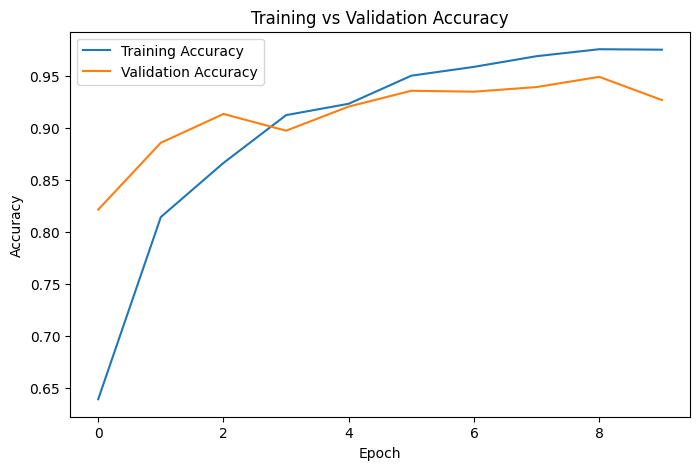

In [ ]:
# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8744 - loss: 1.1531
Test Accuracy: 0.8743749856948853
Test Loss: 1.1531044244766235


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Class names
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Actual labels
y_true = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())

# Model prediction
predictions = model.predict(test_dataset)

# Get class number
y_pred = np.argmax(predictions, axis=1)

# Classification report
report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=class_names
)

print(report)

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step
              precision    recall  f1-score   support

      glioma       0.84      0.77      0.80       400
  meningioma       0.88      0.79      0.83       400
     notumor       0.85      0.99      0.92       400
   pituitary       0.93      0.94      0.94       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



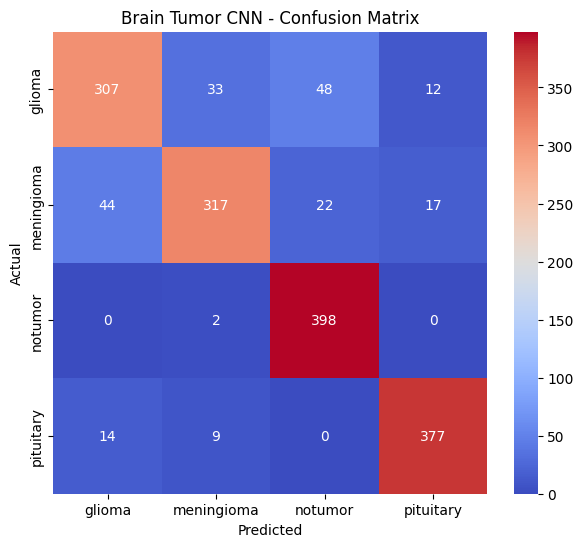

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(cm,annot=True,fmt="d",xticklabels=class_names,yticklabels=class_names,cmap='coolwarm')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Brain Tumor CNN - Confusion Matrix")

plt.show()

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models

# MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Pretrained layers freeze
base_model.trainable = False

print("MobileNetV2 loaded!")

MobileNetV2 loaded!


In [30]:
model_mobilenet = models.Sequential([
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

model_mobilenet.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
model_mobilenet.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model ready!")

MobileNetV2 model ready!


In [32]:
test_loss, test_accuracy = model_mobilenet.evaluate(test_dataset)

print("MobileNetV2 Test Accuracy:", test_accuracy)
print("MobileNetV2 Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - accuracy: 0.2412 - loss: 1.5814
MobileNetV2 Test Accuracy: 0.24124999344348907
MobileNetV2 Test Loss: 1.5813889503479004


In [33]:
from sklearn.metrics import classification_report
import numpy as np

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Actual labels
y_true_mobile = []

for images, labels in test_dataset:
    y_true_mobile.extend(labels.numpy())

# Predictions
predictions_mobile = model_mobilenet.predict(test_dataset)

# Highest probability class
y_pred_mobile = np.argmax(predictions_mobile, axis=1)

# Classification report
print(classification_report(
    y_true_mobile,
    y_pred_mobile,
    labels=[0, 1, 2, 3],
    target_names=class_names
))

50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 355ms/step
              precision    recall  f1-score   support

      glioma       0.31      0.31      0.31       400
  meningioma       0.22      0.03      0.05       400
     notumor       0.18      0.04      0.07       400
   pituitary       0.22      0.58      0.32       400

    accuracy                           0.24      1600
   macro avg       0.23      0.24      0.19      1600
weighted avg       0.23      0.24      0.19      1600



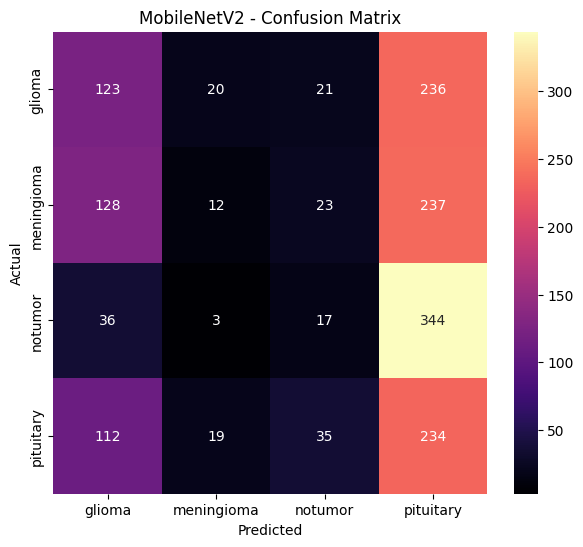

In [36]:
cm_mobile = confusion_matrix(
    y_true_mobile,
    y_pred_mobile
)

plt.figure(figsize=(7, 6))

sns.heatmap(cm_mobile, annot=True, fmt="d", xticklabels=class_names,yticklabels=class_names , cmap = 'magma')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 - Confusion Matrix")

plt.show()

In [37]:
# Test accuracy of both models

cnn_accuracy = test_accuracy

mobilenet_loss, mobilenet_accuracy = model_mobilenet.evaluate( test_dataset, verbose=0)

print("Custom CNN Accuracy     :", cnn_accuracy)
print("MobileNetV2 Accuracy     :", mobilenet_accuracy)

if mobilenet_accuracy > cnn_accuracy:
    print("\nMobileNetV2 performed better.")
elif mobilenet_accuracy < cnn_accuracy:
    print("\nCustom CNN performed better.")
else:
    print("\nBoth models performed equally.")

Custom CNN Accuracy     : 0.24124999344348907
MobileNetV2 Accuracy     : 0.24124999344348907

Both models performed equally.
